In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/home/lolkek3310/python/Подготовка Гомель/Кластеризация/Supermarket dataset for predictive marketing 2023/ECommerce_consumer behaviour.csv')
df.isnull().sum()

df['days_since_prior_order'] = df['days_since_prior_order'].fillna(0)
print(df.isnull().sum())


order_id                  0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_id                0
add_to_cart_order         0
reordered                 0
department_id             0
department                0
product_name              0
dtype: int64


In [3]:
print(df.head())

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   2425083    49125             1          2                 18   
1   2425083    49125             1          2                 18   
2   2425083    49125             1          2                 18   
3   2425083    49125             1          2                 18   
4   2425083    49125             1          2                 18   

   days_since_prior_order  product_id  add_to_cart_order  reordered  \
0                     0.0          17                  1          0   
1                     0.0          91                  2          0   
2                     0.0          36                  3          0   
3                     0.0          83                  4          0   
4                     0.0          83                  5          0   

   department_id  department        product_name  
0             13      pantry  baking ingredients  
1             16  dairy eggs     soy lactosefree  
2          

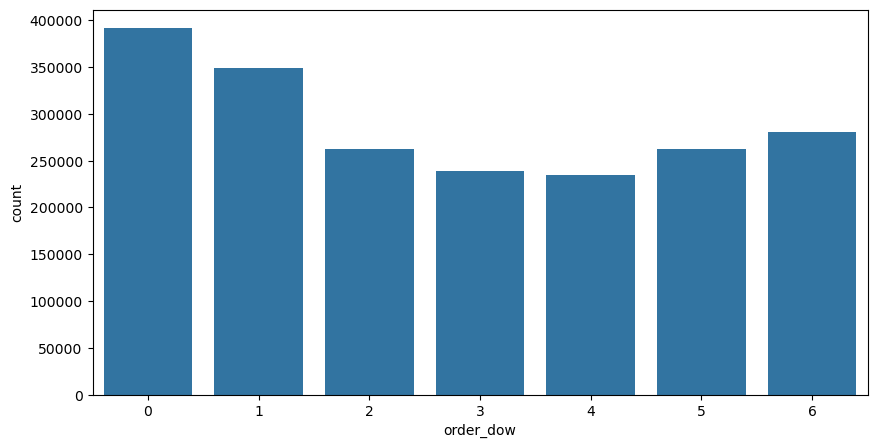

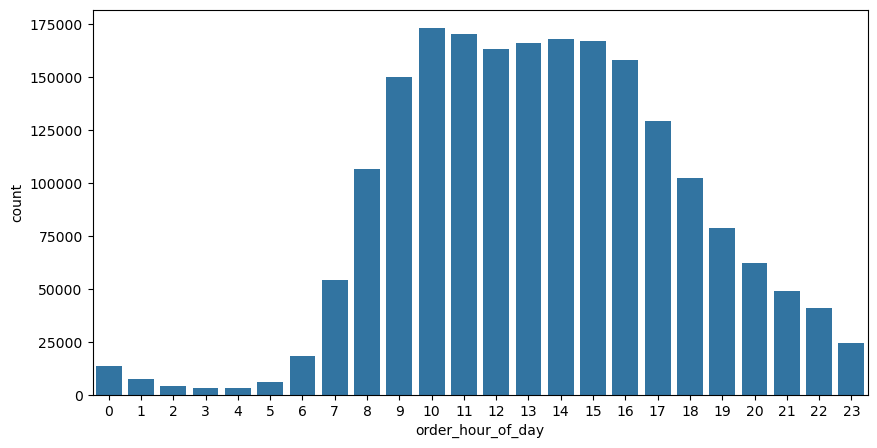

In [4]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='order_dow')
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df,x='order_hour_of_day')
plt.show()

In [5]:
reoder_counts = df['reordered'].value_counts()
recorder_pct = df['reordered'].value_counts(normalize=True) * 100
print(reoder_counts)
print(recorder_pct)

reordered
1    1190986
0     828515
Name: count, dtype: int64
reordered
1    58.974271
0    41.025729
Name: proportion, dtype: float64


/tmp/ipykernel_14867/1350568366.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


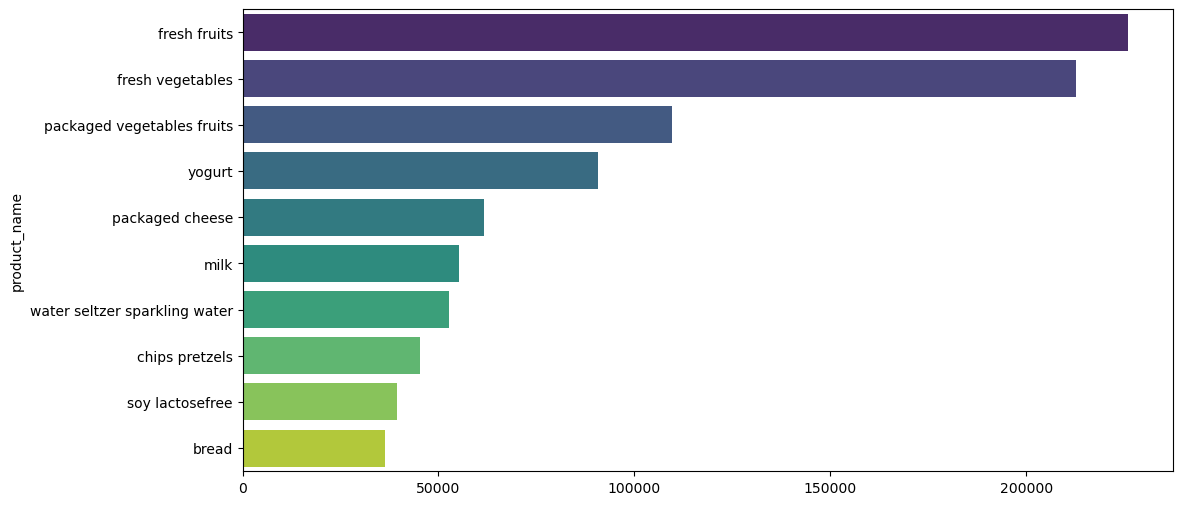

In [6]:
top_products = df['product_name'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.show()

/tmp/ipykernel_14867/248628343.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_departament.values, y=top_departament.index, palette='viridis')


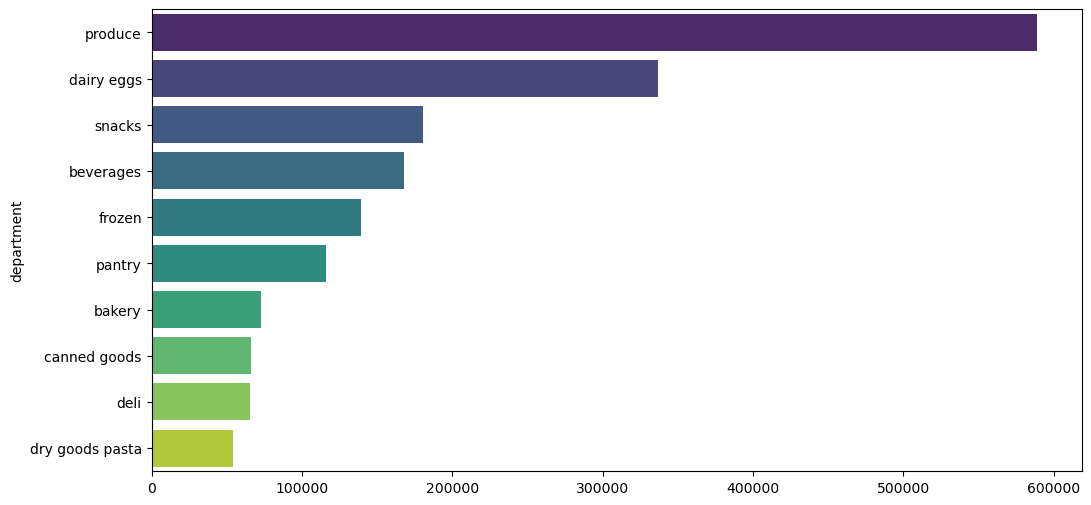

In [7]:
top_departament = df['department'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_departament.values, y=top_departament.index, palette='viridis')
plt.show()

In [8]:
user_features = df.groupby('user_id').agg({

'order_number': 'max',

'days_since_prior_order': 'mean',

'order_hour_of_day': 'mean',

'reordered': 'mean'
}).reset_index()

user_features.columns = ['user_id', 'total_orders', 'avg_days_between_orders', 'avg_order_hour', 'reorder_rate']


print(user_features.head())

   user_id  total_orders  avg_days_between_orders  avg_order_hour  \
0        2             3                 6.818182       10.000000   
1        3            11                12.421053       18.473684   
2        7             3                30.000000       18.000000   
3       10             4                14.000000       15.000000   
4       11             5                30.000000       11.000000   

   reorder_rate  
0      0.363636  
1      0.473684  
2      0.833333  
3      0.433333  
4      0.272727  


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

tmp=['total_orders', 'avg_days_between_orders', 'avg_order_hour', 'reorder_rate']
x=user_features[tmp]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

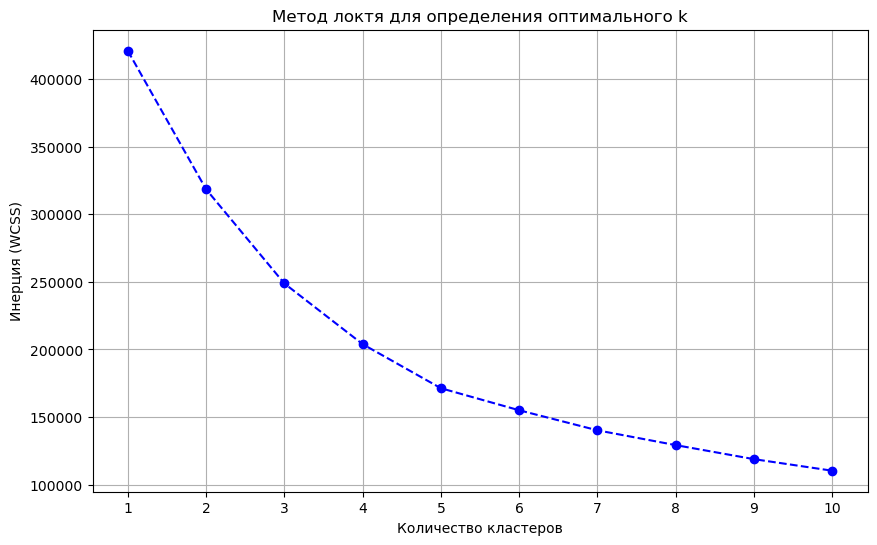

In [10]:
# 1. Создаем пустой список, куда будем записывать значения инерции
wcss = []

# 2. Запускаем цикл от 1 до 10 (range(1, 11) не включает 11)
for i in range(1, 11):
    # Создаем модель K-Means с текущим количеством кластеров i
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    
    # Обучаем модель на наших отмасштабированных данных x_scaled
    kmeans.fit(x_scaled)
    
    # Метод .inertia_ возвращает сумму квадратов расстояний (WCSS)
    # Добавляем это число в наш список
    wcss.append(kmeans.inertia_)

# 3. Рисуем график локтя
plt.figure(figsize=(10, 6))
# По оси X — количество кластеров (от 1 до 10)
# По оси Y — значения инерции из списка wcss
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')

plt.title('Метод локтя для определения оптимального k')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция (WCSS)')
plt.xticks(range(1, 11)) # Чтобы на оси X были все числа от 1 до 10
plt.grid(True)
plt.show()

In [11]:
from sklearn.cluster import KMeans

# 1. Снова определяем список признаков (чтобы избежать NameError)
features_list = ['total_orders', 'avg_days_between_orders', 'avg_order_hour', 'reorder_rate']

# 2. Создаем модель на 4 кластера
model = KMeans(n_clusters=4, random_state=42, n_init=10)

# 3. Обучаем и записываем результат
user_features['cluster'] = model.fit_predict(x_scaled)

# 4. Группируем и считаем средние значения + количество клиентов (size)
# Это даст нам полную картину по каждому сегменту
cluster_analysis = user_features.groupby('cluster').agg({
    'total_orders': 'mean',
    'avg_days_between_orders': 'mean',
    'avg_order_hour': 'mean',
    'reorder_rate': 'mean',
    'user_id': 'count'  # Считаем, сколько людей попало в каждую группу
}).rename(columns={'user_id': 'customer_count'})

print(cluster_analysis)

         total_orders  avg_days_between_orders  avg_order_hour  reorder_rate  \
cluster                                                                        
0           54.803507                 5.649474       13.214319      0.746613   
1            6.417608                 5.866634       13.954134      0.193232   
2            7.370059                26.198302       13.719476      0.461706   
3           15.877139                 9.449610       13.195569      0.753459   

         customer_count  
cluster                  
0                 12774  
1                 27545  
2                 25096  
3                 39858  


In [12]:
# 1. Обучаем модель заново, теперь точно указываем 4 кластера
final_model = KMeans(n_clusters=4, random_state=42, n_init=10)

# 2. Записываем результаты в колонку 'cluster'
user_features['cluster'] = final_model.fit_predict(x_scaled)

# 3. Считаем средние показатели для каждой из 4-х групп
# Это поможет нам дать им "имена" (VIP, Новички и т.д.)
cluster_profiles = user_features.groupby('cluster').agg({
    'total_orders': 'mean',
    'avg_days_between_orders': 'mean',
    'avg_order_hour': 'mean',
    'reorder_rate': 'mean',
    'user_id': 'count' # Добавим подсчет количества людей в каждой группе
}).rename(columns={'user_id': 'customer_count'})

print(cluster_profiles)

         total_orders  avg_days_between_orders  avg_order_hour  reorder_rate  \
cluster                                                                        
0           54.803507                 5.649474       13.214319      0.746613   
1            6.417608                 5.866634       13.954134      0.193232   
2            7.370059                26.198302       13.719476      0.461706   
3           15.877139                 9.449610       13.195569      0.753459   

         customer_count  
cluster                  
0                 12774  
1                 27545  
2                 25096  
3                 39858  


In [13]:
# 1. Берем из user_features только ID пользователя и номер его кластера
user_clusters = user_features[['user_id', 'cluster']]

# 2. Объединяем (merge) это с основной таблицей покупок по колонке 'user_id'
df_final = df.merge(user_clusters, on='user_id')

# Теперь у каждой строки с покупкой товара появился номер кластера покупателя
print(df_final.head())

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   2425083    49125             1          2                 18   
1   2425083    49125             1          2                 18   
2   2425083    49125             1          2                 18   
3   2425083    49125             1          2                 18   
4   2425083    49125             1          2                 18   

   days_since_prior_order  product_id  add_to_cart_order  reordered  \
0                     0.0          17                  1          0   
1                     0.0          91                  2          0   
2                     0.0          36                  3          0   
3                     0.0          83                  4          0   
4                     0.0          83                  5          0   

   department_id  department        product_name  cluster  
0             13      pantry  baking ingredients        1  
1             16  dairy eggs     soy lactose

In [14]:
# Создаем пустой словарь для хранения топ-товаров каждого кластера
cluster_recommendations = {}

# Цикл по всем 4 кластерам (0, 1, 2, 3)
for i in range(4):
    # Фильтруем данные только по текущему кластеру
    cluster_data = df_final[df_final['cluster'] == i]
    
    # Берем топ-5 самых популярных товаров в этом кластере
    top_products = cluster_data['product_name'].value_counts().head(5).index.tolist()
    
    # Сохраняем в словарь
    cluster_recommendations[i] = top_products

# Выводим результат
for cluster, products in cluster_recommendations.items():
    print(f"Кластер {cluster} обычно покупает: {', '.join(products)}")

Кластер 0 обычно покупает: fresh fruits, fresh vegetables, packaged vegetables fruits, yogurt, milk
Кластер 1 обычно покупает: fresh vegetables, fresh fruits, packaged vegetables fruits, yogurt, packaged cheese
Кластер 2 обычно покупает: fresh vegetables, fresh fruits, packaged vegetables fruits, yogurt, packaged cheese
Кластер 3 обычно покупает: fresh fruits, fresh vegetables, packaged vegetables fruits, yogurt, packaged cheese


In [15]:
def get_recommendation(user_id):
    # 1. Узнаем кластер пользователя
    cluster = user_features[user_features['user_id'] == user_id]['cluster'].iloc[0]
    
    # 2. Узнаем, что он УЖЕ покупал (чтобы не предлагать то же самое)
    bought_products = df[df['user_id'] == user_id]['product_name'].unique()
    
    # 3. Берем топ-товары его кластера
    cluster_top = cluster_recommendations[cluster]
    
    # 4. Выбираем товары, которые он еще НЕ пробовал
    recommendations = [p for p in cluster_top if p not in bought_products]
    
    return recommendations

# Проверим на любом пользователе (например, с ID 2)
test_user = user_features['user_id'].iloc[0]
print(f"Рекомендация для пользователя {test_user}: {get_recommendation(test_user)}")

Рекомендация для пользователя 2: ['fresh vegetables', 'packaged vegetables fruits', 'yogurt']


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Создаем целевую переменную (Target)
# Допустим, "Лояльный" — это тот, у кого reorder_rate > 0.5 (больше половины корзины — повторы)
# .astype(int) превратит True/False в 1 и 0
user_features['is_loyal'] = (user_features['reorder_rate'] > 0.5).astype(int)

# 2. Выбираем признаки для обучения (убираем id и саму целевую переменную)
# Мы берем только те данные, которые мы знаем о клиенте в начале
X = user_features[['total_orders', 'avg_days_between_orders', 'avg_order_hour']]
y = user_features['is_loyal']

# 3. Делим данные на Обучающую и Тестовую выборки
# test_size=0.2 — значит 20% данных мы оставим для проверки модели
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (84218, 3)
Размер тестовой выборки: (21055, 3)


In [17]:
# 1. Создаем модель "Случайный лес"
# n_estimators=100 — это значит 100 деревьев в лесу
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Обучаем модель (она ищет связи между признаками и лояльностью)
clf.fit(X_train, y_train)

# 3. Просим модель сделать предсказание на тестовых данных
y_pred = clf.predict(X_test)

# 4. Проверяем точность
print("Результаты модели:")
print(classification_report(y_test, y_pred))

Результаты модели:
              precision    recall  f1-score   support

           0       0.67      0.65      0.66      9599
           1       0.71      0.73      0.72     11456

    accuracy                           0.69     21055
   macro avg       0.69      0.69      0.69     21055
weighted avg       0.69      0.69      0.69     21055

